In [20]:
import kagglehub

# This automatically downloads the latest version of the Intel dataset
# directly into your notebook's working environment!
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Dataset downloaded to path:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset downloaded to path: /kaggle/input/intel-image-classification


In [21]:
import os

# 1. Point directly to the folder kagglehub just made for you
base_path = '/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2'

train_dir = os.path.join(base_path, 'seg_train/seg_train')
test_dir = os.path.join(base_path, 'seg_test/seg_test')

# 2. Load the training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=(150, 150),
    batch_size=32
)

# 3. Load the testing data
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=(150, 150),
    batch_size=32
)

# 4. Save your class names
class_names = train_ds.class_names
print("Awesome! Classes successfully loaded:", class_names)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Awesome! Classes successfully loaded: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [22]:
# Import essential libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import kagglehub

In [23]:
# Optimize dataset performance by caching images in memory
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

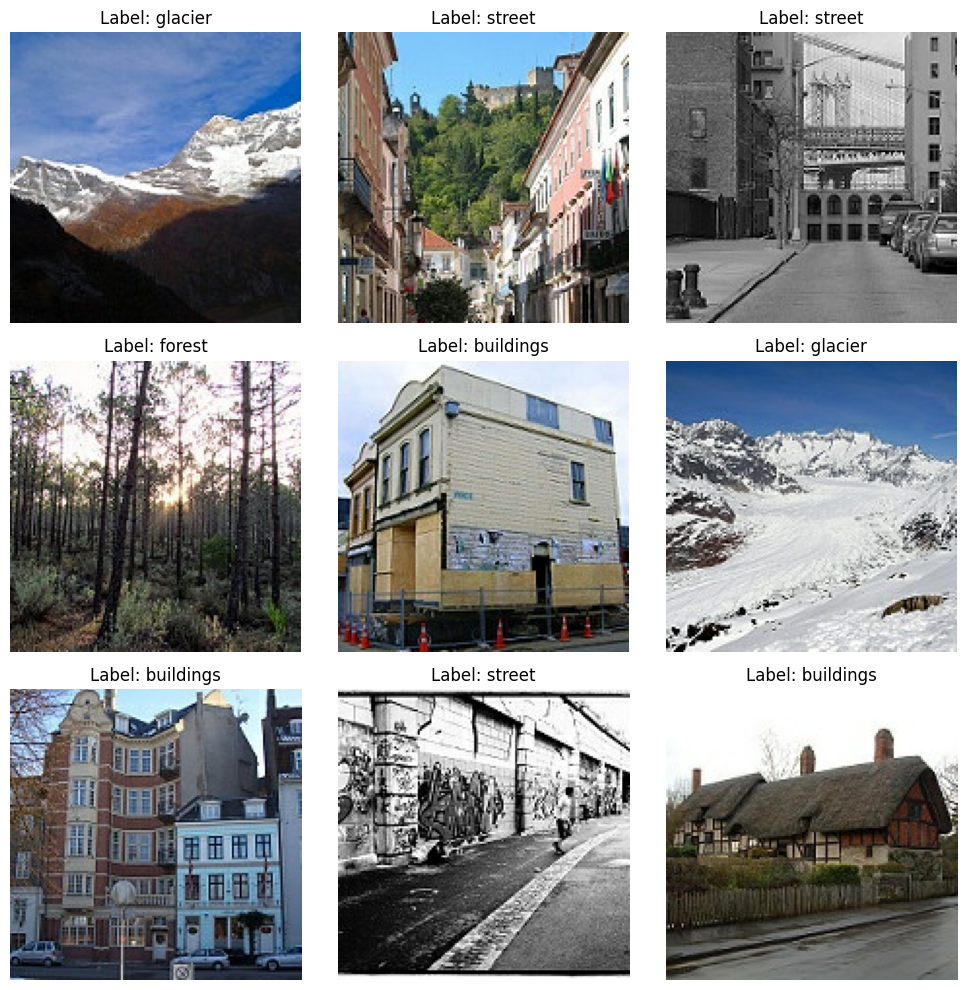

In [24]:
# Display a 3x3 grid of sample images with their text labels
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        # Convert tensors to standard integers to show colors correctly
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Label: {class_names[labels[i]]}")
        plt.axis('off')
plt.tight_layout()
plt.show()

In [25]:
# Build the Sequential Convolutional Neural Network
model = models.Sequential([
    # Inputs are 150x150 pixels with 3 color channels (RGB)
    layers.Input(shape=(150, 150, 3)),

    # Automatically scales down pixels from [0-255] to [0-1]
    layers.Rescaling(1./255),

    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 3 (Crucial for deep natural scene textures)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flattening and Dense processing layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),                    # Helps protect the model from overfitting
    layers.Dense(6, activation='softmax')   # 6 units for our 6 scenery categories
])

# View full layer structural breakdowns
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [27]:
# 1. Compile the network
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Train for just 1 single epoch so it finishes in a couple of minutes!
history = model.fit(
    train_ds,
    epochs=1,
    validation_data=val_ds
)

439/439 ━━━━━━━━━━━━━━━━━━━━ 718s 2s/step - accuracy: 0.5822 - loss: 1.0648 - val_accuracy: 0.7097 - val_loss: 0.7615


In [32]:
# Evaluate the model on the validation dataset (Matches Cell 18 format)
test_loss, test_acc = model.evaluate(val_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 419ms/step - accuracy: 0.7097 - loss: 0.7615
Test Accuracy: 0.7097
Test Loss: 0.7615


In [33]:
from sklearn.metrics import classification_report
import numpy as np

# 1. Gather all true labels and predicted labels from the validation set
y_true = []
y_pred_classes = []

for images, labels in val_ds:
    # Make predictions for the current batch
    preds = model.predict(images, verbose=0)

    # Store the actual class and the highest predicted class
    y_true.extend(labels.numpy())
    y_pred_classes.extend(np.argmax(preds, axis=1))

# 2. Print out the classification report (Matches Cell 20 format)
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

Classification Report:

              precision    recall  f1-score   support

   buildings       0.72      0.78      0.75       437
      forest       0.94      0.90      0.92       474
     glacier       0.68      0.63      0.65       553
    mountain       0.81      0.49      0.61       525
         sea       0.49      0.78      0.60       510
      street       0.84      0.71      0.77       501

    accuracy                           0.71      3000
   macro avg       0.75      0.72      0.72      3000
weighted avg       0.74      0.71      0.71      3000



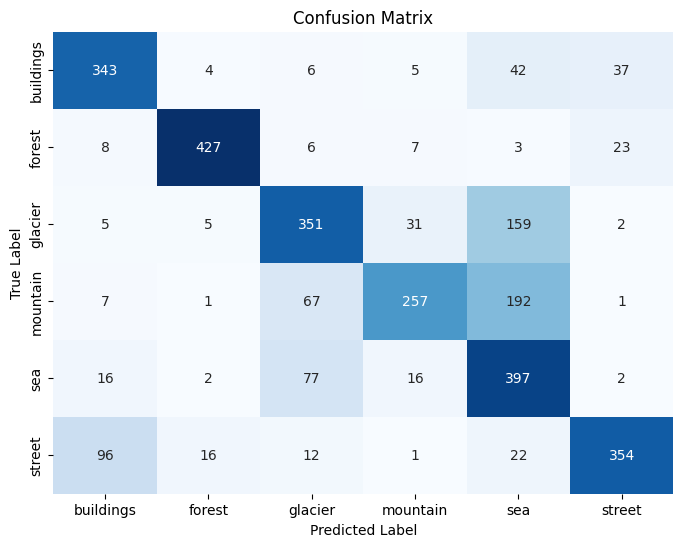

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compute the confusion matrix (Matches Cell 21 format)
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# 2. Plot the confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [35]:
# Predict class probabilities for test/validation images (Matches Cell 22 format)
for images, labels in val_ds.take(1):
    # Predict probabilities for the current batch of images
    predictions = model.predict(images)

    # Convert probabilities to class labels
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = labels.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


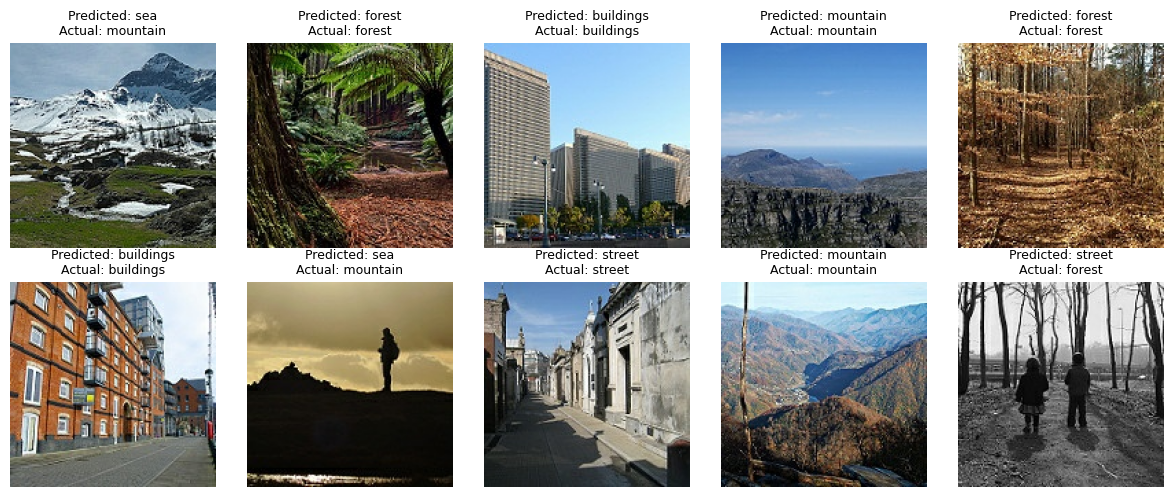

In [36]:
# Plot 10 test images with predictions (Matches Cell 24 format)
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Display the scenery image
    plt.imshow(images[i].numpy().astype("uint8"))

    # Look up the actual names using your class array
    predicted_name = class_names[predicted_classes[i]]
    actual_name = class_names[true_classes[i]]

    plt.title(f"Predicted: {predicted_name}\nActual: {actual_name}", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


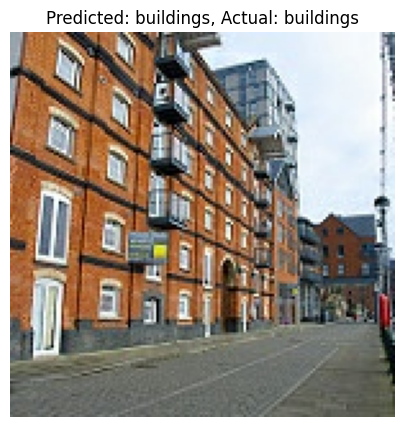

In [37]:
# Predict a single image (Matches Cell 25 format)
for images, labels in val_ds.take(1):
    index = 5  # You can change this index to view different specific images

    # Expand dimensions so it looks like a batch of 1 image: (1, 150, 150, 3)
    single_image = tf.expand_dims(images[index], axis=0)

    # Run the prediction and find the highest confidence label
    predicted_label = np.argmax(model.predict(single_image))
    actual_label = labels[index].numpy()

    # Look up the human-readable text names from your class list
    predicted_name = class_names[predicted_label]
    actual_name = class_names[actual_label]

    # Display the final single image prediction verification
    plt.figure(figsize=(5, 5))
    plt.imshow(images[index].numpy().astype("uint8"))
    plt.title(f"Predicted: {predicted_name}, Actual: {actual_name}")
    plt.axis('off')
    plt.show()